# 01. create_agent로 에이전트 만들기

> LangChain V1의 핵심 함수 `create_agent` 한 줄로 ReAct 에이전트를 만들 수 있어요. 그 위에 미들웨어 데코레이터로 로직을 끼워 넣는 V1 스타일을 배웁니다.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. `create_agent` 함수로 LangChain V1 에이전트를 생성하고 실행할 수 있어요
2. `system_prompt` 파라미터로 에이전트의 페르소나와 동작을 제어할 수 있어요
3. `@wrap_model_call` 미들웨어로 런타임에 모델을 동적으로 교체할 수 있어요
4. `@dynamic_prompt`로 컨텍스트 기반 동적 시스템 프롬프트를 구현할 수 있어요
5. `@before_model` / `@after_model` 훅으로 모델 호출 전후 커스텀 로직을 삽입할 수 있어요

## 사전 지식

- LangGraph `StateGraph`, `AgentState`, `add_messages` 기초 (Part 02)
- `init_chat_model`로 모델 초기화하기 (Part 02 - 02-Models)
- `07-Streaming-Steps.ipynb`에서 배운 스텝 단위 스트리밍

## 에이전트(Agent)란?

에이전트는 **LLM(추론 엔진)**과 **도구(Tool)**를 결합하여 복잡한 작업을 반복적으로 수행하는 시스템이에요. 에이전트는 주어진 작업에 대해 추론하고, 필요한 도구를 선택하며, 목표를 향해 루프를 반복해요.

> 🔑 **핵심 개념**: 에이전트를 **요리사**에 비유할 수 있어요. 요리사(LLM)는 레시피(시스템 프롬프트)를 보고, 주방 도구(Tool)를 골라 사용하며, 맛을 보고(관찰) 다시 조리(루프)하는 과정을 반복해요. `create_agent`는 이 주방 전체를 자동으로 세팅해주는 함수예요.

Part 02~04에서는 `StateGraph`로 직접 노드와 엣지를 구성했어요. Part 05부터는 LangChain V1의 `create_agent` 함수를 사용해요. 이 함수가 에이전트 루프 그래프를 자동으로 구성해줘요.

### StateGraph 직접 구성 vs create_agent 비교

| 항목 | `StateGraph` 직접 구성 (Part 02~04) | `create_agent` (Part 05~) |
|------|-------------------------------------|--------------------------|
| **코드량** | 노드, 엣지, 조건부 엣지 직접 정의 | 한 줄로 에이전트 생성 |
| **유연성** | 커스텀 그래프 구조 자유롭게 설계 | 표준 에이전트 루프 자동 구성 |
| **미들웨어** | 직접 노드에 로직 삽입 | `middleware` 파라미터로 선언적 주입 |
| **적합한 상황** | 비표준 워크플로우 | 대부분의 에이전트 개발 |

> 💡 **핵심 정리**: V0의 `create_react_agent`는 `langgraph.prebuilt`에서 임포트했어요. V1의 `create_agent`는 `langchain.agents`에서 임포트해요. 패키지 경로가 달라진 것이 V1의 핵심 변화예요.

### 에이전트 루프(Agent Loop)

```mermaid
flowchart TD
    A["사용자 입력<br/>Human Message"] --> B["모델 노드<br/>LLM 추론"]
    B --> C{"도구 호출<br/>필요 여부"}
    C -- "도구 호출" --> D["ToolNode<br/>도구 실행"]
    D --> B
    C -- "최종 답변" --> E["최종 응답<br/>AI Message"]

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef tool fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef decision fill:#f8d7da,stroke:#dc3545,color:#721c24

    class A input
    class B process
    class D tool
    class E output
    class C decision
```

### `create_agent` 주요 파라미터

| 파라미터 | 타입 | 설명 |
|----------|------|------|
| `model` | `str` 또는 `BaseChatModel` | 추론 엔진. 문자열 또는 `init_chat_model` 인스턴스 |
| `tools` | `list` | 에이전트가 사용할 도구 목록 |
| `system_prompt` | `str` | 에이전트 페르소나·동작 정의 |
| `middleware` | `list` | 모델 호출 전후에 실행되는 훅 목록 |
| `context_schema` | `TypedDict` / `dataclass` | 런타임 컨텍스트 타입 정의 (둘 다 가능) |
| `name` | `str` | 멀티 에이전트 식별용 이름 (snake_case) |

## 환경 설정

In [1]:
# ---------------------------------------------------
# 환경 변수 로드
# ---------------------------------------------------
# .env 파일에서 OPENAI_API_KEY 등 API 키를 불러와요
from dotenv import load_dotenv

load_dotenv()

True

In [ ]:
# ---------------------------------------------------
# LangSmith 추적 설정 (선택)
# ---------------------------------------------------
# LANGCHAIN_API_KEY가 .env에 있으면 자동으로 추적이 활성화돼요
import os

# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "05-Agent-Development"

## 1. 기본 에이전트 생성

에이전트를 만드는 방법은 두 가지예요.

- **방법 1**: `create_agent("provider:model", ...)` — 문자열 직접 전달
- **방법 2**: `init_chat_model()`로 모델 인스턴스를 생성 후 전달

> 💡 **핵심 정리**: V0의 `create_react_agent`는 `langgraph.prebuilt`에서 임포트했어요. V1의 `create_agent`는 `langchain.agents`에서 임포트해요. 패키지 경로가 달라진 것이 V1의 핵심 변화예요.

> ⚠️ **자주 하는 실수**: `tools` 파라미터에 `ToolNode` 인스턴스를 전달하면 안 돼요. `@tool` 데코레이터로 만든 함수 목록을 직접 넘겨야 해요. `ToolNode`는 `create_agent`가 내부적으로 자동 생성해요.

In [6]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model

model = init_chat_model("openai:gpt-4o-mini")
agent = create_agent(model, tools=[])

# Or
# agent = create_agent("openai:gpt-4o-mini", tools=[])

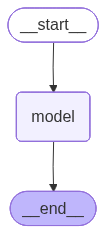

In [7]:
from IPython.display import Image, display

agent

In [8]:
from langchain.messages import HumanMessage

result = agent.invoke(
    {"messages": [HumanMessage(content="대한민국 수도는?")]}
)


In [9]:
for chunk in agent.stream(
    {"messages": [HumanMessage(content="파이썬이란 무엇인가요? 한 문장으로 설명해주세요.")]},
    stream_mode="updates",
):
    for node_name, node_output in chunk.items():
        print(f"\n--- {node_name} 노드 출력 ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()  # 메시지를 보기 좋게 출력해요


--- model 노드 출력 ---
================================== Ai Message ==================================

파이썬은 간결하고 읽기 쉬운 문법을 가진 고급 프로그래밍 언어로, 다양한 용도로 사용됩니다.


## 2. 모델 옵션 설정

`init_chat_model`에 추가 옵션을 전달하여 모델 동작을 세밀하게 제어할 수 있어요.

| 옵션 | 설명 | 기본값 |
|------|------|--------|
| `temperature` | 응답 다양성 (0=일관됨, 1=창의적) | 모델별 기본값 |
| `max_tokens` | 최대 생성 토큰 수 | 무제한 |
| `timeout` | 요청 타임아웃 (초) | 무제한 |

> 💡 **실무 팁**: 프로덕션 환경에서는 `timeout`을 반드시 설정하세요. 설정하지 않으면 LLM API 장애 시 요청이 무한 대기할 수 있어요. 30~60초가 일반적인 권장 값이에요.

In [10]:
model_with_options = init_chat_model(
    "openai:gpt-4o-mini",
    temperature=0,
    max_tokens=500,
    timeout=30
)

agent_with_options = create_agent(model_with_options, tools=[])

result = agent_with_options.invoke(
    {"messages": [HumanMessage(content="머신러닝을 한 문장으로 설명해주세요")]}
)

result

{'messages': [HumanMessage(content='머신러닝을 한 문장으로 설명해주세요', additional_kwargs={}, response_metadata={}, id='3e6d3c43-71e7-48f8-8433-3bccf92b10b4'),
  AIMessage(content='머신러닝은 데이터에서 패턴을 학습하여 예측이나 결정을 자동으로 수행하는 인공지능의 한 분야입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 30, 'prompt_tokens': 18, 'total_tokens': 48, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_196f526a25', 'id': 'chatcmpl-Dkfc9szp2oOMNu7h7enjTzw4AKpTY', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e712f-e675-7eb0-9b5c-b61cd4e31fd4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 18, 'output_tokens': 30, 'total_tokens': 48, 'input_token_details': {'audio': 0, 'c

## 3. system_prompt로 에이전트 페르소나 설정

`system_prompt` 파라미터(V0의 `prompt` → V1에서 이름 변경)로 에이전트의 역할과 응답 스타일을 정의해요.

> 🔑 **핵심 개념**: `system_prompt`는 모든 대화 턴에 걸쳐 일관되게 적용돼요. 에이전트가 "누구인지", "어떻게 답해야 하는지"를 규정하는 설계 문서예요.

> ⚠️ **자주 하는 실수**: V0에서 `prompt` 파라미터를 썼다면 V1에서는 `system_prompt`로 변경해야 해요. `prompt`는 V1에서 더 이상 지원하지 않아요.

In [11]:
agent_with_prompt = create_agent(
    model,
    system_prompt=(
        "당신은 친절한 한국어 AI 튜터예요. "
        "모든 답변은 한국어로 간결하게 2~3문장으로 제공해요. "
        "기술 용어는 첫 등장 시 한글(영어) 형태로 병기해요."
    )
)

result = agent_with_prompt.invoke(
    {"messages": [HumanMessage(content="LLM이 뭐야?")]}
)

result

{'messages': [HumanMessage(content='LLM이 뭐야?', additional_kwargs={}, response_metadata={}, id='5a3f575d-d6d7-4cfe-b354-7084468562d6'),
  AIMessage(content='LLM은 "대규모 언어 모델"의 약자로, 자연어 처리(NLP) 분야에서 사용되는 인공지능 모델을 의미해요. 대량의 텍스트 데이터를 학습하여 자연어 이해와 생성 작업을 수행할 수 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 73, 'total_tokens': 129, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2767f2907f', 'id': 'chatcmpl-Dkfe54Fey6VSkDezdJ2AuKWNV8eoV', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e7131-b97c-7103-b9bb-0b1f84248ec6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 56, 'total_tokens': 12

In [13]:
agent_with_prompt = create_agent(
    model,
    system_prompt=(
        "당신은 친절한 한국어 AI 튜터예요. "
        "모든 답변은 한국어로 간결하게 2~3문장으로 제공해요. "
        "기술 용어는 첫 등장 시 한글(영어) 형태로 병기해요."
        "새가 이해할 수 있게 모든 내용을 이모지로 표현해서 대답 해줘."
    )
)

result = agent_with_prompt.invoke(
    {"messages": [HumanMessage(content="LLM이 뭐야?")]}
)

result

{'messages': [HumanMessage(content='LLM이 뭐야?', additional_kwargs={}, response_metadata={}, id='564c8411-d6c0-451f-9ddc-82c18b29ad7e'),
  AIMessage(content='LLM(대규모 언어 모델)은 방대한 양의 데이터를 바탕으로 자연어를 이해하고 생성하는 인공지능 기술이에요. 🧠📚💬', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 92, 'total_tokens': 131, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_53ab0cb954', 'id': 'chatcmpl-DkffITSa6HzQGaIF8ddvVkadBiQ1O', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e7132-e1c6-7713-a621-d0bd825016fa-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 92, 'output_tokens': 39, 'total_tokens': 131, 'input_token_details': {'audio': 0, 'c

## 4. 동적 모델 선택: @wrap_model_call

런타임 상태나 컨텍스트에 따라 모델을 교체해야 할 때 `@wrap_model_call` 미들웨어를 사용해요.

> **왜 동적 모델 선택이 필요할까요?** 모든 요청에 고성능 모델을 쓰면 비용이 치솟고, 저렴한 모델만 쓰면 복잡한 질문에 품질이 떨어져요. 동적 모델 선택은 **요청 특성에 따라 비용과 품질의 균형**을 자동으로 맞춰줘요. 마치 레스토랑에서 간단한 음료는 셀프 서비스로, 코스 요리는 전담 셰프가 담당하는 것과 같아요.

```mermaid
flowchart LR
    A["요청 수신<br/>ModelRequest"] --> B["wrap_model_call<br/>미들웨어"]
    B --> C{"상태 분석<br/>(메시지 수, 복잡도 등)"}
    C -- "단순" --> D["경량 모델<br/>gpt-4o-mini"]
    C -- "복잡" --> E["고성능 모델<br/>gpt-4o"]
    D --> F["handler 호출<br/>실제 LLM 실행"]
    E --> F
    F --> G["응답 반환<br/>ModelResponse"]

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404
    classDef decision fill:#f8d7da,stroke:#dc3545,color:#721c24

    class A input
    class B,D,E,F process
    class G output
    class C decision
```

> ⚠️ **자주 하는 실수**: `request.model = new_model` 직접 할당은 deprecated예요. 반드시 `request.override(model=new_model)`을 사용해요. `override()`는 불변 객체처럼 새로운 `ModelRequest`를 반환해요.

### ModelRequest 주요 속성

| 속성 | 설명 |
|------|------|
| `model` | 사용할 `BaseChatModel` 인스턴스 |
| `system_prompt` | 시스템 프롬프트 (선택) |
| `messages` | 대화 메시지 리스트 (시스템 제외) |
| `tools` | 사용 가능한 도구 리스트 |
| `tool_choice` | 도구 선택 설정 |
| `state` | 현재 `AgentState` (messages 포함) |
| `runtime` | 런타임 정보 (context, store 접근) |
| `model_settings` | 추가 모델 설정 dict |

In [16]:
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse

lightweight_model = init_chat_model("openai:gpt-4o-mini")
advanced_model = init_chat_model("openai:gpt-4o")

@wrap_model_call
def dynamic_model_selection(request: ModelRequest, handler) -> ModelResponse:
    """마지막 메시지 길이에 따라 모델을 동적으로 선택해요"""
    # 마지막 메시지 내용의 길이를 기준으로 모델 선택
    last_message_content = request.state["messages"][-1].content
    char_count = len(last_message_content)
    print(f"입력 길이: {char_count}자")

    if char_count > 20:
        # 긴 질문 → 고성능 모델 + 상세 답변 유도
        new_request = request.override(
            model=advanced_model,
            system_prompt="상세하고 구조적으로 답변해요. 예시를 포함해요.",
        )
        # 고성능 모델 선택 (긴 질문)
    else:
        # 짧은 질문 → 경량 모델 + 간결한 답변 유도
        new_request = request.override(
            model=lightweight_model,
            system_prompt="한 문장으로 간결하게 답변해요.",
        )
        # 경량 모델 선택 (짧은 질문)

    return handler(new_request)

agent_dynamic = create_agent(
    model=lightweight_model,
    tools=[],
    middleware=[dynamic_model_selection]
)



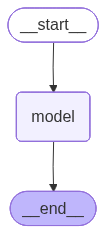

In [17]:
agent_dynamic

In [19]:
result = agent_dynamic.invoke({"messages": HumanMessage(content="AI 와 LLM의 차이")})
result

입력 길이: 12자


{'messages': [HumanMessage(content='AI 와 LLM의 차이', additional_kwargs={}, response_metadata={}, id='cb256874-127a-498b-b2c6-eb830ffc3038'),
  AIMessage(content='AI는 인공지능 전체를 의미하고, LLM은 대규모 언어 모델로서 AI의 한 분야입니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 27, 'prompt_tokens': 30, 'total_tokens': 57, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_7b5f1cba44', 'id': 'chatcmpl-DkgBFZOA6Lv7RNjW5MSKOqV79h6Sk', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e7151-1cd1-7630-9347-01369e3d6242-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 30, 'output_tokens': 27, 'total_tokens': 57, 'input_token_details': {'audio': 0, 'cache_read': 0

In [21]:
result = agent_dynamic.invoke({"messages": HumanMessage(content="LLM과 머신러닝, 딥러닝에 대해 전문가 수준으로 각 기술의 개념과 사용처에 대해 설명해줘.")})
print(result)

입력 길이: 51자
{'messages': [HumanMessage(content='LLM과 머신러닝, 딥러닝에 대해 전문가 수준으로 각 기술의 개념과 사용처에 대해 설명해줘.', additional_kwargs={}, response_metadata={}, id='dc88ac53-9014-4749-a543-b7cc641c204b'), AIMessage(content="자연어 처리(NLP)와 인공지능(AI) 분야에서 LLM, 머신러닝, 딥러닝은 서로 관련이 있지만 다양한 수준의 개념과 응용 분야를 가진 기술들입니다. 아래에서는 각각의 기술에 대한 개념적 설명과 사용처를 구조적으로 정리하겠습니다.\n\n### 1. LLM (Large Language Model)\n\n**개념:**\nLLM은 대규모 데이터셋에서 학습하여 인간처럼 텍스트를 이해하고 생성할 수 있는 능력을 가진 언어 모델입니다. LLM은 자연어의 문법, 의미, 맥락을 이해하기 위해 대용량 텍스트 데이터를 사용하여 훈련됩니다. 일반적으로 수억에서 수십억 개의 매개변수를 포함하며, GPT (Generative Pre-trained Transformer) 시리즈와 같은 모델들이 이에 해당합니다.\n\n**사용처:**\n- **자연어 처리(NLP):** 텍스트 생성, 번역, 요약, 감정 분석 등.\n  - 예: 이메일 작성 도우미, 자동 번역기\n- **챗봇 및 가상 비서:** 사용자와 자연스러운 대화를 통해 질문에 답변하거나 작업을 수행합니다.\n  - 예: 구글 어시스턴트, 애플 시리\n- **컨텐츠 생성 및 편집:** 블로그 포스트, 기사, 광고 카피 등을 자동으로 작성 및 편집.\n  - 예: 마케팅 캠페인 문구 작성\n\n### 2. 머신러닝 (Machine Learning)\n\n**개념:**\n머신러닝은 데이터로부터 자동으로 모델을 학습하여 예측, 분류, 군집화 등을 수행하는 알고리즘의 집합입니다. 머신러닝 모델은 패턴을 인식하고 데이터의 통계적 특성을 기반으로 결정을 내립니다. 지도 학습(s

## 5. 동적 시스템 프롬프트: @dynamic_prompt

`system_prompt` 문자열은 고정값이에요. 런타임에 컨텍스트에 따라 다른 프롬프트를 적용하려면 `@dynamic_prompt` 미들웨어를 사용해요.

**동작 흐름:**
1. 에이전트 호출 시 `context` 파라미터로 컨텍스트 전달
2. `@dynamic_prompt` 함수가 `request.runtime.context`로 컨텍스트 접근
3. 컨텍스트 값에 따라 다른 시스템 프롬프트 반환

> 🔑 **핵심 개념**: `context_schema`는 `TypedDict`, `dataclass`, Pydantic 모델 모두로 정의할 수 있어요. 이 노트북은 `TypedDict`를 쓰지만, `02-Tools-V1.ipynb`와 `05-Runtime-Context.ipynb`에서는 `dataclass`를 사용해요. 어떤 방식이든 `create_agent`에 `context_schema`를 전달하면 IDE에서 타입 검사를 받을 수 있어요. (출처: [Structured output 공식 문서](https://docs.langchain.com/oss/python/langchain/structured-output.md))

> 💡 **실무 팁**: 동적 프롬프트는 다국어 서비스, A/B 테스트, 사용자 역할 기반 응답에 아주 유용해요. 코드를 수정하지 않고도 컨텍스트만 바꿔서 에이전트 동작을 제어할 수 있어요.

In [ ]:
from typing import TypedDict
from langchain.agents.middleware import dynamic_prompt, ModelRequest

class ResponseContext(TypedDict):
    format: str
    language: str
    max_length: int

@dynamic_prompt
def format_aware_prompt(request: ModelRequest) -> str:
    ctx = request.runtime.context or {}

    fmt = ctx.get("format", "default")
    lang = ctx.get("language", "ko")
    max_len = ctx.get("max_length", 200)

    # 언어 설정
    lang_instruction = "한국어로" if lang == "ko" else "in English"

    # 형식에 따라 다른 시스템 프롬프트 반환
    if fmt == "sns":
        return (
            f"{lang_instruction} SNS 게시글 형식으로 답변해요. "
            f"이모지를 적절히 사용하고 {max_len}자 이내로 작성해요."
        )
    elif fmt == "article":
        return (
            f"{lang_instruction} 뉴스 기사 형식으로 작성해요. "
            f"제목, 본문 구조를 갖추고 {max_len}자 이내로 작성해요."
        )
    else:  # default
        return (
            f"{lang_instruction} 간결하게 답변해요. "
            f"{max_len}자 이내로 핵심만 설명해요."
        )

agent_dynamic_prompt = create_agent(
    model="openai:gpt-4o-mini",
    middleware=[format_aware_prompt],
    context_schema=ResponseContext
)



In [ ]:
user_a_schema = ResponseContext(format="sns", language="ko", max_length=100)
result = agent_dynamic_prompt.invoke({"messages": [HumanMessage(content="AI 가 우리 일상을 바꾸고 있다는 주제로 글을 써줘.")]}, context=user_a_schema)

result

{'messages': [HumanMessage(content='AI 가 우리 일상을 바꾸고 있다는 주제로 글을 써줘.', additional_kwargs={}, response_metadata={}, id='6c6fbc0c-58e4-4576-9f4b-567cdb8e8c18'),
  AIMessage(content='🌟 AI가 우리 일상을 혁신하고 있어요! 🤖✨ 스마트 가전에서 개인 맞춤형 서비스까지, 매일 더 편리한 삶을 선사해주네요! 💡🔗 #AI #일상변화 #미래기술', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 60, 'total_tokens': 117, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_8324b7be19', 'id': 'chatcmpl-DkgsLTHMnSkCDv1l0WtrE3whZ9DYq', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e7179-e188-77a1-9f4c-fd6e01c93744-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 60, 'output_tokens': 57, 'total_tokens

In [25]:
user_b_schema = ResponseContext(format="article", language="ko", max_length=1000)
result = agent_dynamic_prompt.invoke({"messages": [HumanMessage(content="AI 가 우리 일상을 바꾸고 있다는 주제로 글을 써줘.")]}, context=user_b_schema)

result

{'messages': [HumanMessage(content='AI 가 우리 일상을 바꾸고 있다는 주제로 글을 써줘.', additional_kwargs={}, response_metadata={}, id='4b231c40-e7a8-41f7-a3c8-4253f2adc9c8'),
  AIMessage(content='**제목: AI, 우리의 일상을 혁신하다**\n\n최근 몇 년간 인공지능(AI)이 우리의 일상에 빠르게 스며들고 있다. 과거에는 영화나 소설 속의 상상 속 존재로 여겨졌던 AI가 이제는 우리 생활의 여러 분야에서 중요한 역할을 하고 있다.\n\n먼저, 일상적인 업무에서 AI의 도입이 두드러지고 있다. 기업들은 AI 기반의 데이터 분석 툴을 활용해 경영 의사 결정을 내리고 있으며, 고객 서비스 분야에서도 AI 챗봇이 24시간 고객 문의를 처리하고 있다. 이는 인간 직원의 부담을 덜어주고, 보다 효율적인 서비스 제공이 가능해지도록 하고 있다.\n\n또한, AI는 개인화된 경험을 제공하는 데 큰 역할을 하고 있다. 음악 스트리밍 서비스나 온라인 쇼핑 플랫폼은 AI 알고리즘을 통해 사용자에게 맞춤형 추천을 제공하여 더욱 편리한 소비 경험을 만들어 주고 있다. 이러한 변화는 소비자들의 만족도를 높이고, 기업의 매출 증가에도 긍정적인 영향을 미치고 있다.\n\nAI 기술의 발전은 의료 분야에서도 빼놓을 수 없는 주제다. 인공지능은 환자의 진단과 치료를 지원하는 데 사용되고 있으며, 특히 영상 분석을 통해 조기 진단의 정확성을 높이는 데 기여하고 있다. 이는 생명을 구하는 데 결정적인 역할을 할 수 있으며, 의료 서비스의 질을 한층 향상시키고 있다.\n\n하지만 이러한 변화가 항상 긍정적인 것만은 아니다. AI의 발전에 따른 일자리 감소와 프라이버시 침해 문제 등도 심각한 사회적 이슈로 떠오르고 있다. 많은 전문가들은 AI 도입이 일자리를 대체하는 대신 새로운 일자리를 창출할 가능성에 주목하고 있지만, 이에 대한 준비와 대책이 필요하다고 강조하고 있다.\n\n

## 6. 미들웨어 훅: @before_model / @after_model

> 이 절은 Part 06 미들웨어 단원의 **맛보기**예요. 여기서는 `before_model`/`after_model` 두 지점만 써보고, 전체 후크 지도와 노드/랩 스타일 구분은 `06_Middleware/01-Middleware-Basics.ipynb`에서 정리해요.

`@wrap_model_call`이 모델 호출 요청 자체를 수정한다면, `@before_model`과 `@after_model`은 에이전트 상태(state)에 접근해서 전처리·후처리를 해요.

| 데코레이터 | 실행 시점 | 반환값 | 주요 용도 |
|------------|-----------|--------|----------|
| `@before_model` | 모델 호출 직전 | `dict` (state 업데이트) 또는 `None` | 쿼리 재작성, 메시지 전처리 |
| `@after_model` | 모델 호출 직후 | `dict` (state 업데이트) 또는 `None` | 로깅, 응답 후처리 |

> 💡 **핵심 정리**: `@before_model`에서 `dict`를 반환하면 그 내용이 `AgentState`에 업데이트돼요. `messages` 키를 반환하면 `add_messages` 리듀서가 적용되어 **메시지가 추가**돼요 (기존 메시지를 교체하려면 동일한 `id`를 가진 메시지를 반환하거나 `RemoveMessage`로 명시적으로 제거해야 해요). `None`을 반환하면 state를 변경하지 않아요.

> 💡 **실무 팁**: 쿼리 재작성(Query Rewriting)은 RAG 시스템에서 검색 품질을 높이는 핵심 기법이에요. `@before_model`에서 사용자 입력을 더 명확한 형태로 변환하면 LLM의 답변 품질도 올라가요. 아래 예제는 새 `HumanMessage`를 추가(append)하는 간단한 방식이고, 마지막 메시지가 재작성본이므로 모델이 최신 쿼리를 우선적으로 참고해요.

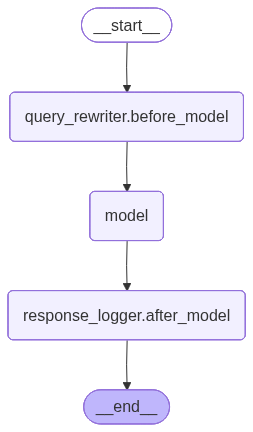

In [29]:
from langchain.agents.middleware import before_model, after_model, AgentState
from langgraph.runtime import Runtime
from typing import Any

@before_model
def query_rewriter(state: AgentState, reutime: Runtime) -> dict[str, Any] | None:
    last_message = state["messages"][-1]
    original_query = last_message.content
    print(f"[before model] 원본 쿼리: {original_query}")

    if len(original_query) < 10 and "?" not in original_query:
        rewritten = f"{original_query}에 대해 상세히 설명해주세요."
        print(f"[before model] 재작성 쿼리: {rewritten}")
        return {
            "messages": [HumanMessage(content=rewritten)]
        }
    return None

@after_model
def response_logger(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """모델 호출 후 대화 상태를 로깅해요"""
    total_msgs = len(state["messages"])
    last_response = state["messages"][-1].content
    print(f"[after_model] 총 메시지 수: {total_msgs}개")
    print(f"[after_model] 응답 길이: {len(last_response)}자")
    # 상태 변경 없음 → None 반환
    return None


agent_with_hooks = create_agent(
    model="openai:gpt-4o-mini",
    middleware=[query_rewriter, response_logger]
)

agent_with_hooks

In [30]:
result = agent_with_hooks.invoke(
    {"messages": [HumanMessage(content="강화학습")]}
)

print(result["messages"][-1].content)


[before model] 원본 쿼리: 강화학습
[before model] 재작성 쿼리: 강화학습에 대해 상세히 설명해주세요.
[after_model] 총 메시지 수: 3개
[after_model] 응답 길이: 1602자
강화학습(Reinforcement Learning, RL)은 기계 학습(Machine Learning)의 한 분야로, 에이전트(Agent)가 환경(Environment)과 상호작용을 하며 보상(Reward)을 극대화하는 행동 전략을 학습하는 방법론입니다. 강화학습은 게임, 로봇 제어, 자율주행차 등 다양한 응용 분야에서 사용됩니다.

### 기본 구성 요소

1. **에이전트(Agent)**: 의사 결정을 내리고 환경과 상호작용하는 주체입니다.
2. **환경(Environment)**: 에이전트가 상호작용하는 시스템이며, 에이전트의 행동에 따라 상태를 변화시킵니다.
3. **상태(State)**: 환경의 현재 상황을 나타내는 정보입니다. 에이전트가 환경의 상태를 관찰하고 이에 따라 행동을 결정합니다.
4. **행동(Action)**: 에이전트가 환경에서 선택할 수 있는 행동의 집합입니다. 각 행동은 환경에 영향을 미칩니다.
5. **보상(Reward)**: 에이전트가 특정 행동을 취한 후 환경으로부터 받는 피드백입니다. 보상은 에이전트가 특정 행동을 얼마나 유익하게 또는 유해하게 평가하는지를 나타냅니다.
6. **정책(Policy)**: 주어진 상태에서 에이전트가 선택할 행동을 결정하는 전략입니다. 정책은 확률적으로 정의될 수 있으며, 에이전트를 통해 학습됩니다.
7. **가치 함수(Value Function)**: 특정 상태에서 얻을 수 있는 장기적인 보상의 기대값을 나타내는 함수입니다. 이는 에이전트가 어떤 상태에서 얼마나 좋은지를 평가하는 데 사용됩니다.

### 학습 과정

강화학습의 목표는 에이전트가 보상을 극대화하는 행동 정책을 학습하는 것입니다. 이를 위해 일반적으로 사용되는 알고리즘은 다음과 같습니다:

1. **탐험(Explo

In [31]:
result = agent_with_hooks.invoke(
    {"messages": [HumanMessage(content="파이썬에서 리스트와 딕셔너리의 차이가 뭔가요?")]}
)

print(result["messages"][-1].content)


[before model] 원본 쿼리: 파이썬에서 리스트와 딕셔너리의 차이가 뭔가요?
[after_model] 총 메시지 수: 2개
[after_model] 응답 길이: 1056자
파이썬에서 리스트(List)와 딕셔너리(Dictionary)는 두 가지 기본적인 데이터 구조로, 각각의 용도와 특징이 다릅니다. 아래에 두 데이터 구조의 주요 차이점을 설명하겠습니다.

### 리스트 (List)
1. **정의**: 순서가 있는 데이터의 집합입니다. 단순히 값들을 순차적으로 저장할 수 있는 자료형입니다.
2. **구조**: 대괄호 `[]`를 사용하여 생성합니다.
   - 예: `my_list = [1, 2, 3, 4]`
3. **인덱스**: 각 요소는 0부터 시작하는 인덱스를 가집니다. 인덱스를 사용하여 요소에 접근할 수 있습니다.
   - 예: `my_list[0]`는 `1`을 반환합니다.
4. **중복**: 리스트는 중복된 값을 허용합니다. 동일한 값의 요소를 여러 번 포함할 수 있습니다.
5. **용도**: 주로 순서가 중요한 데이터의 집합을 다룰 때 사용합니다.

### 딕셔너리 (Dictionary)
1. **정의**: 키-값(key-value) 쌍으로 이루어진 데이터의 집합입니다. 각 키는 고유해야 하며, 값을 통해 키에 접근할 수 있습니다.
2. **구조**: 중괄호 `{}`를 사용하여 생성합니다.
   - 예: `my_dict = {'a': 1, 'b': 2, 'c': 3}`
3. **키**: 각 값은 고유한 키에 의해 식별됩니다. 키는 해시 가능해야 하며, 문자열, 숫자 등 다양한 자료형을 사용할 수 있습니다.
   - 예: `my_dict['a']`는 `1`을 반환합니다.
4. **중복**: 딕셔너리는 같은 키를 두 번 사용할 수 없습니다. 만약 같은 키를 사용하는 경우, 마지막에 지정한 값으로 덮어씌워집니다.
5. **용도**: 키-값 쌍을 저장하여 데이터에 빠르게 접근하거나, 특정한 조건에 따라 데이터를 정리할 필요가 있을 때 사용합니다.

##

## 7. 클래스 기반 미들웨어와 재시도 로직

> 📌 **심화(선택)**: 이 절(§7)과 다음 절(§8)은 미들웨어 심화 내용이에요. 처음 보는 경우 가볍게 훑고 넘어가도 괜찮아요. 미들웨어는 `06_Middleware` 단원에서 본격적으로 다뤄요.

복잡한 미들웨어 로직은 클래스로 구조화하거나, `@wrap_model_call`로 재시도 로직을 구현할 수 있어요.

> 🔑 **핵심 개념**: `AgentMiddleware`를 상속한 클래스는 `state_schema`로 커스텀 상태를 정의할 수 있어요. 미들웨어가 추가적인 상태 필드를 필요로 할 때 사용해요.

> 💡 **실무 팁**: LLM API 호출은 네트워크 오류, 속도 제한(rate limit), 서버 과부하 등으로 일시적으로 실패할 수 있어요. `@wrap_model_call`로 재시도 로직을 미들웨어로 캡슐화하면 에이전트 코드가 깔끔해지고 재사용성이 높아져요.

In [32]:
# ---------------------------------------------------
# 재시도 로직 미들웨어
# ---------------------------------------------------
# wrap_model_call: 모델 호출 전체를 감싸는 미들웨어
# 재시도 로직을 미들웨어로 캡슐화하면 에이전트 코드가 깔끔해져요
from typing import Callable
import time


@wrap_model_call
def retry_on_failure(
    request: ModelRequest,
    handler: Callable[[ModelRequest], ModelResponse],
) -> ModelResponse:
    """모델 호출 실패 시 최대 3회 재시도해요"""
    max_retries = 3
    last_error = None

    for attempt in range(max_retries):
        try:
            return handler(request)
        except Exception as e:
            last_error = e
            if attempt < max_retries - 1:
                wait_seconds = 2 ** attempt  # 지수 백오프: 1초, 2초
                print(f"[재시도 {attempt + 1}/{max_retries}] 오류: {e} → {wait_seconds}초 후 재시도")
                time.sleep(wait_seconds)
            else:
                print(f"[실패] 최대 재시도 횟수 초과: {e}")
    raise last_error


agent_with_retry = create_agent(
    model=init_chat_model("openai:gpt-4o-mini"),
    middleware=[retry_on_failure],
)

# 재시도 미들웨어 에이전트 생성 완료

In [33]:
from langchain.agents import AgentState
from langchain.agents.middleware import AgentMiddleware

# 커스텀 상태 스키마: AgentState를 확장
class TrackedState(AgentState):
    call_count: int  # 모델 호출 횟수 추적


class CallCountMiddleware(AgentMiddleware):
    """모델 호출 횟수를 state에 기록하는 미들웨어예요"""
    state_schema = TrackedState  # 커스텀 상태 등록
    tools = []

    def before_model(self, state: TrackedState, runtime: Runtime) -> dict[str, Any] | None:
        # 현재 호출 횟수 증가
        current_count = state.get("call_count", 0)
        print(f"[CallCountMiddleware] 모델 호출 횟수: {current_count + 1}")
        return {"call_count": current_count + 1}


agent_tracked = create_agent(
    model=init_chat_model("openai:gpt-4o-mini"),
    middleware=[CallCountMiddleware()],  # 클래스 인스턴스 전달
)

# TrackedState 사용: messages와 call_count 모두 포함
result = agent_tracked.invoke(
    {
        "messages": [HumanMessage(content="안녕하세요!")],
        "call_count": 0,  # 초기값
    }
)

print(f"최종 호출 횟수: {result.get('call_count', 'N/A')}")
print(f"응답: {result['messages'][-1].content}")

[CallCountMiddleware] 모델 호출 횟수: 1
최종 호출 횟수: 1
응답: 안녕하세요! 어떻게 도와드릴까요?


## 8. 미들웨어 체이닝 (심화·선택)

여러 미들웨어를 `middleware` 리스트에 순서대로 등록하면 체인으로 실행돼요. 미들웨어 체이닝은 **양파 껍질** 구조라고 생각하면 이해하기 쉬워요 -- 요청은 바깥에서 안쪽으로 들어가고, 응답은 안쪽에서 바깥으로 나와요.

```
요청 → middleware[0] → middleware[1] → middleware[2] → 모델
응답 ← middleware[0] ← middleware[1] ← middleware[2] ← 모델
```

| 훅 타입 | 실행 순서 | 이유 |
|---------|----------|------|
| `before_model` | 순서대로 (0 → 1 → 2) | 전처리를 차례로 적용 |
| `after_model` | 역순 (2 → 1 → 0) | 후처리를 스택처럼 LIFO |

> ⚠️ **자주 하는 실수**: `@before_model` 미들웨어가 `messages`를 반환했을 때 뒤이어 등록된 `@before_model` 미들웨어는 업데이트된 messages를 받아요. 순서에 따라 동작이 달라질 수 있으니 미들웨어 순서를 신중하게 설계해요.

In [34]:
# ---------------------------------------------------
# 미들웨어 체이닝 예시
# ---------------------------------------------------
# 여러 미들웨어를 리스트로 등록하면 순서대로 실행돼요

@before_model
def add_context_prefix(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """메시지에 언어 지시 접두어를 추가해요"""
    last_msg = state["messages"][-1]
    enhanced = f"[한국어로 답변] {last_msg.content}"
    print(f"[add_context_prefix] 접두어 추가: {enhanced}")
    return {"messages": [HumanMessage(content=enhanced)]}


@after_model
def trim_response(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """응답이 너무 길면 안내 메시지를 추가해요"""
    last_response = state["messages"][-1].content
    if len(last_response) > 300:
        print(f"[trim_response] 긴 응답 감지 ({len(last_response)}자)")
    return None


# 미들웨어 체인: add_context_prefix → (모델 실행) → trim_response
agent_chained = create_agent(
    model=init_chat_model("openai:gpt-4o-mini"),
    middleware=[
        add_context_prefix,  # before_model: 요청 전 실행
        trim_response,       # after_model: 응답 후 실행
    ],
)

result = agent_chained.invoke(
    {"messages": [HumanMessage(content="What is quantum computing?")]}
)
# 최종 응답:
print(result["messages"][-1].content)

[add_context_prefix] 접두어 추가: [한국어로 답변] What is quantum computing?
[trim_response] 긴 응답 감지 (523자)
양자 컴퓨팅은 양자역학의 원리를 이용하여 정보를 처리하는 컴퓨팅 방식입니다. 전통적인 컴퓨터는 비트(bit)를 사용하여 정보를 0 또는 1의 상태로 저장하고 처리하는 반면, 양자 컴퓨터는 큐비트(qubit)를 사용합니다. 큐비트는 0과 1의 상태를 동시에 가질 수 있는 중첩(superposition) 상태를 가질 수 있으며, 이는 양자 컴퓨터가 특정 문제를 훨씬 더 빠르게 해결할 수 있는 가능성을 제공합니다.

양자 컴퓨팅의 주요 특징 중 하나는 얽힘(entanglement) 현상인데, 이는 두 개의 큐비트가 서로 강하게 연결되어 한 큐비트의 상태가 변화하면 다른 큐비트의 상태도 동시에 변화하는 현상입니다. 이로 인해 양자 컴퓨터는 여러 계산을 동시에 수행할 수 있어 고성능 계산을 가능하게 합니다.

양자 컴퓨팅은 암호 해독, 복잡한 시스템의 모델링, 최적화 문제 해결 등 다양한 분야에서 큰 잠재력을 가지고 있으며, 현재 많은 연구가 진행되고 있습니다. 하지만 기술적인 도전과 과제가 많아 실용화에는 아직 시간이 필요합니다.


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **`create_agent`**: LangChain V1의 표준 에이전트 팩토리 함수. `langchain.agents`에서 임포트. V0의 `create_react_agent`를 대체해요
- **`system_prompt`**: 에이전트 페르소나·응답 스타일 설정 파라미터. V0의 `prompt`에서 이름 변경됨
- **`@wrap_model_call`**: 모델 호출 요청을 가로채서 모델·시스템 프롬프트 등을 런타임에 교체. `request.override()`로 불변 수정
- **`@dynamic_prompt`**: `context_schema`(`TypedDict`·`dataclass` 등)와 함께 사용. `runtime.context`로 컨텍스트 접근해서 동적 시스템 프롬프트 생성
- **`@before_model` / `@after_model`**: 에이전트 상태(`AgentState`)에 접근하는 전처리·후처리 훅. `dict` 반환 시 state 업데이트
- **미들웨어 체이닝**: 여러 미들웨어를 리스트로 등록. 등록 순서대로 실행되며 each 미들웨어가 독립적으로 state를 수정할 수 있어요
- **V1 핵심 변화**: 스트리밍 노드 이름이 `"agent"` → `"model"`로 변경됨. `ValidationNode` 제거(자동 처리). Python 3.10+ 필수

## 다음 노트북 예고

다음 `02-Tools-V1.ipynb`에서는 **LangChain V1 Tool 정의**를 배워요. `@tool` 데코레이터로 에이전트가 사용할 도구를 만들고, `ToolRuntime`으로 런타임 컨텍스트를 도구 내부에서 접근하는 방법을 알아봐요. 여기서 배운 `create_agent`에 실제 도구를 붙여서 동작하는 에이전트를 완성할 수 있어요.